# Нейроннная сеть прямого распространения
**Задание:** 
- **Вход НС:** Некоторый набор финнасовых показателей (курсы акций, валют, цены на сырьё).
- **На выходе НС:** Предсказение на L шагов вперёд одного из показателей.
- **Изменяемые параметры:** M - ширина окна наблюдения, D - глубина задержек, $N_s$ - число элементов в скрытом слое

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf


gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✓ Найдено GPU: {len(gpus)}")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu.name}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ Память GPU будет выделяться по мере необходимости")
    except RuntimeError as e:
        print(f"⚠ Ошибка настройки памяти: {e}")
    
    # 3. Устанавливаем GPU как устройство по умолчанию
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print(f"✓ Активный GPU: {gpus[0].name}")


USE_SAVED_MODEL = False # load model from model.keras file
    

M = 30 # Сколько дней смотрим назад
D = 1 # Размер лкна внутри основго окна
L = 1 # На сколько дней вперёд прогнозируем
NEURONS = 64 # Колчиество нейронов в скрытом слое
EPOCHS = 50 # Сколько раз обучаем сеть
BATCH = 32 # Размер пакета при обучении

✓ Найдено GPU: 1
  GPU 0: /physical_device:GPU:0
✓ Память GPU будет выделяться по мере необходимости
✓ Активный GPU: /physical_device:GPU:0


# Load Data

In [123]:
tickers = ['GC=F', 'SI=F']
data = yf.download(tickers, start='2020-01-01', progress=False)

gold = data['Close']['GC=F']
silver = data['Close']['SI=F']
data = pd.DataFrame({'gold': gold, 'silver': silver})
data.head()

,gold,silver
Date,,
2020-01-02,1524.500000,17.966000
2020-01-03,1549.199951,18.068001
2020-01-06,1566.199951,18.097000
2020-01-07,1571.800049,18.316000
2020-01-08,1557.400024,18.087999


# Preparing data

In [124]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
data_scaled

array([[0.01228813, 0.06029319],
       [0.01871857, 0.06128019],
       [0.02314439, 0.06156079],
       ...,
       [0.9409284 , 0.69956937],
       [0.97690773, 0.74844452],
       [0.97021689, 0.73390102]])

In [125]:
X, y = [], []

for i in range(M, len(data_scaled) - L):
    start_idx = i - M + (i - M) % D
    
    indices = range(start_idx, i, D)
    window = data_scaled[list(indices)]

    target = data_scaled[i + L, 0]
    X.append(window.flatten())
    y.append(target)

X, y = np.array(X), np.array(y)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Обучающая: {len(X_train)}, Тестовая: {len(X_test)}\n")
print(f"Кол-во признаков: {X_train.shape[1]}")

Обучающая: 1220, Тестовая: 306

Кол-во признаков: 60


# Create model

In [126]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)), # Указываем количество входный нейронов = кол-во признаков
    tf.keras.layers.Dense(NEURONS, activation='relu', kernel_initializer="he_normal"), # Число нейронов в скрытом слое, функция активации, Dense - полносвязный слой
    tf.keras.layers.Dense(1) # Один полносвязный нейрон на выходе - цена золота
])

model.compile(optimizer='adam', loss='mse', metrics=['mae']) # 'adam' - интеллектуальный гралиентный спуск, loss - функция потерь, matrics - дополнгительные метрики для отслеживания
# adam: подстраивает скорость обучения для каждого параметра
model.summary()
# кол-во входных параметров: 60 x 64 + 60 (bias)
# кол-во выходеных параметров: 64 + 1

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

# Learning model

In [127]:
import os.path


if not USE_SAVED_MODEL:
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )
elif USE_SAVED_MODEL and os.path.isfile('model.keras'):
    model = tf.keras.models.load_model('model.keras')
else:
    raise Exception("model.keras not exist: Try set USE_SAVED_MODEL to False")

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0061 - mae: 0.0582 - val_loss: 0.0108 - val_mae: 0.0980
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.3004e-04 - mae: 0.0214 - val_loss: 0.0016 - val_mae: 0.0343
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.3797e-04 - mae: 0.0166 - val_loss: 8.7381e-04 - val_mae: 0.0247
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.7658e-04 - mae: 0.0153 - val_loss: 9.4732e-04 - val_mae: 0.0258
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.3805e-04 - mae: 0.0145 - val_loss: 9.2932e-04 - val_mae: 0.0257
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.0303e-04 - mae: 0.0138 - val_loss: 5.2816e-04 - val_mae: 0.0192
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.7521e-04 - mae: 0.0131 - val_loss: 6.7734e-04 - val_mae: 0.0219
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5513e-04 - mae: 0.0127 - val_loss: 4.5257e-04 - val_mae: 0.0176
Epoch 9/50
31/31 ━━

# Model score

In [128]:
y_pred = model.predict(X_test)

y_test_real = scaler.inverse_transform(
    np.column_stack([y_test, np.zeros(len(y_test))])
)[:, 0]
y_pred_real = scaler.inverse_transform(
    np.column_stack([y_pred.flatten(), np.zeros(len(y_pred))])
)[:, 0]

mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print(f"RMSE: ${rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
RMSE: $190.68
R²: 0.9283
MAPE: 4.15%


In [129]:
# Save current model
model.save("model.keras")

# Learning graph

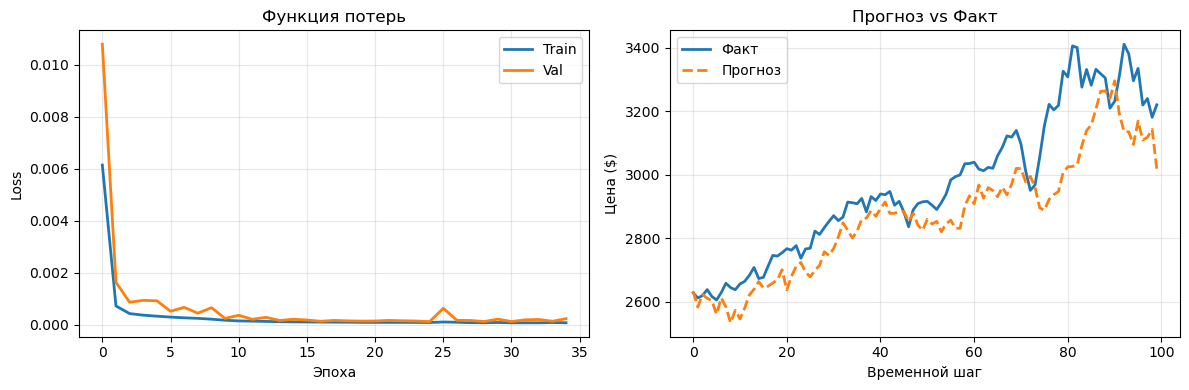

In [130]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train', linewidth=2)
plt.plot(history.history['val_loss'], label='Val', linewidth=2)
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(y_test_real[:100], label='Факт', linewidth=2)
plt.plot(y_pred_real[:100], label='Прогноз', linewidth=2, linestyle='--')
plt.title('Прогноз vs Факт')
plt.xlabel('Временной шаг')
plt.ylabel('Цена ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()